**CSP=(X,D,C)**

CSP (Constraint Satisfaction Problem) Framework = (variable, domain, constraint)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from src.csp import CSP
from src.constraints import BinaryConstraint
from src.solvers import (
    backtracking_search,
    backtracking_search_mrv,
    backtracking_search_mrv_degree,
    backtracking_search_with_stats,
    backtracking_search_mrv_with_stats,
    backtracking_search_mrv_degree_with_stats,
    backtracking_search_forward_checking,
    backtracking_search_dynamic_mrv_forward_checking,
    backtracking_search_dynamic_fc_with_stats,
    backtracking_search_ac3,
    backtracking_search_ac3_with_stats,
    backtracking_search_lcv,
    backtracking_search_lcv_with_stats,
)
from src.generators import (
    generate_graph_coloring_csp
)
from src.experiments import (
    run_solver_experiment
)
from src.constraint_propagation import (
    ac3    
)

c:\Users\niush\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


<h1> Map Coloring Example </h1>

In [2]:
variables = [
    "WA",
    "NT",
    "SA",
    "Q",
]

colors = [
    "Red",
    "Green",
    "Blue",
]

domains = {
    variable: colors.copy()
    for variable in variables
}

constraints = [

    BinaryConstraint(
        "WA",
        "NT",
    ),

    BinaryConstraint(
        "WA",
        "SA",
    ),

    BinaryConstraint(
        "NT",
        "SA",
    ),

    BinaryConstraint(
        "NT",
        "Q",
    ),

    BinaryConstraint(
        "SA",
        "Q",
    ),
]

neighbors = {

    "WA": [
        "NT",
        "SA",
    ],

    "NT": [
        "WA",
        "SA",
        "Q",
    ],

    "SA": [
        "WA",
        "NT",
        "Q",
    ],

    "Q": [
        "NT",
        "SA",
    ],
}

In [3]:
problem = CSP(
    variables,
    domains,
    constraints,
    neighbors,
)

For this step, we will create the neighbors manually, but a better design is to have CSP itself create this graph later based on the constraints.

In [4]:
problem.validate()

problem.get_domains_copy()

{'WA': ['Red', 'Green', 'Blue'],
 'NT': ['Red', 'Green', 'Blue'],
 'SA': ['Red', 'Green', 'Blue'],
 'Q': ['Red', 'Green', 'Blue']}

In [5]:
assignment = {
    "WA":"Red",
    "NT":"Green",
    "SA":"Blue",
}

In [6]:
problem.is_consistent(
    assignment
)

True

In [7]:
assignment = {
    "WA":"Red",
    "NT":"Red",
}

In [8]:
problem.is_consistent(
    assignment
)

False

Naive Backtracking

In [9]:
solution = backtracking_search(
    problem
)

solution

{'WA': 'Red', 'NT': 'Green', 'SA': 'Blue', 'Q': 'Red'}

<h1> MRV — Minimum Remaining Values </h1>

Idea:
Choose the variable that has the fewest remaining choices.

In [10]:
solution_basic = backtracking_search(
    problem
)

solution_basic

{'WA': 'Red', 'NT': 'Green', 'SA': 'Blue', 'Q': 'Red'}

In [11]:
solution_mrv = backtracking_search_mrv(
    problem
)

solution_mrv

{'WA': 'Red', 'NT': 'Green', 'SA': 'Blue', 'Q': 'Red'}

<h1> Degree Heuristic + MRV Tie Breaking </h1>

Degree Idea 

Choose the variable that:</br>
has the most constraints with other variables.

High impact variable first

**MRV + Degree combination**

Algorithm:

First MRV: Lowest Domain.

If multiple options are equal: Highest Degree.

In [12]:
solution_mrv_degree = backtracking_search_mrv_degree(
    problem
)

solution_mrv_degree

{'NT': 'Red', 'SA': 'Green', 'WA': 'Blue', 'Q': 'Blue'}

In CSP, each Assignment is a Node in the Search Tree.

In [13]:
solution, stats = backtracking_search_with_stats(
    problem
)

solution

{'WA': 'Red', 'NT': 'Green', 'SA': 'Blue', 'Q': 'Red'}

In [14]:
stats.summary()

{'Nodes Visited': 5, 'Assignments Tried': 7, 'Backtracks': 0}

We still don't see the power of heuristics, so let's build a real benchmark.

<h3> Instrumenting Heuristic Solvers </h3>

Comparing:

Naive Backtracking</br>
vs</br>
MRV Backtracking</br>
vs</br>
MRV + Degree

Metric:

Nodes Visited</br>
Assignments Tried</br>
Backtracks</br>

In [15]:
solution_mrv_stats, stats_mrv = backtracking_search_mrv_with_stats(problem)

solution_mrv_stats

{'WA': 'Red', 'NT': 'Green', 'SA': 'Blue', 'Q': 'Red'}

In [16]:
stats_mrv.summary()

{'Nodes Visited': 5, 'Assignments Tried': 7, 'Backtracks': 0}

Heuristics show their value when the search space is large or the constraints are hard.

In [17]:
solution_mrv_degree_stats, stats_mrv_degree = (
    backtracking_search_mrv_degree_with_stats(
        problem
    )
)

solution_mrv_degree_stats

{'NT': 'Red', 'SA': 'Green', 'WA': 'Blue', 'Q': 'Blue'}

In [18]:
stats_mrv_degree.summary()

{'Nodes Visited': 5, 'Assignments Tried': 9, 'Backtracks': 0}

That is, Degree has an effect on the order of selection, but because the problem is simple, we have not yet entered an area where a real difference can be seen.

In [2]:
random_problem = generate_graph_coloring_csp(
    num_variables=20,
    num_colors=4,
    edge_probability=0.2,
)

random_problem

In [20]:
len(random_problem.variables)

20

In [21]:
len(random_problem.constraints)

41

In [22]:
random_problem.neighbors["X0"]

['X1', 'X2', 'X11', 'X13', 'X15']

<h1> Benchmark Framework </h1>

In [9]:
solvers = [
    (
        "Naive",
        backtracking_search_with_stats
    ),
    (
        "MRV",
        backtracking_search_mrv_with_stats
    ),
    (
        "MRV+Degree",
        backtracking_search_mrv_degree_with_stats
    )
]

In [24]:
problem = generate_graph_coloring_csp(
    num_variables=30,
    num_colors=4,
    edge_probability=0.2,
)

results = []

for name, solver in solvers:

    result = run_solver_experiment(
        problem,
        solver,
    )

    result["Algorithm"] = name

    results.append(result)

In [25]:
benchmark_df = pd.DataFrame(
    results
)

benchmark_df

,Nodes Visited,Assignments Tried,Backtracks,Success,Execution Time,Algorithm
0,1518819,6075226,1518788,True,78.168910,Naive
1,1518819,6075226,1518788,True,84.343621,MRV
2,57,178,26,True,0.002932,MRV+Degree


<h1> Multi Trial Benchmark </h1>

making a loop of trials

In [26]:
all_results = []

trials = 10

for trial in range(trials):
    problem = generate_graph_coloring_csp(
        num_variables=30,
        num_colors=4,
        edge_probability=0.2,
    )

    for name, solver in solvers:
        result = run_solver_experiment(
            problem,
            solver,
        )
        result["Algorithm"] = name
        result["Trial"] = trial
        all_results.append(result)

In [27]:
benchmark_df = pd.DataFrame(
    all_results
)

benchmark_df

,Nodes Visited,Assignments Tried,Backtracks,Success,Execution Time,Algorithm,Trial
0,1842,7311,1811,True,0.098546,Naive,0
1,1842,7311,1811,True,0.096039,MRV,0
2,38,99,7,True,0.001296,MRV+Degree,0
3,10232,40875,10201,True,0.529599,Naive,1
4,10232,40875,10201,True,0.602475,MRV,1
5,37,92,6,True,0.002307,MRV+Degree,1
6,276462,1105792,276431,True,12.726634,Naive,2
7,276462,1105792,276431,True,13.635751,MRV,2
8,123,449,92,True,0.005366,MRV+Degree,2
9,150368,601419,150337,True,6.348615,Naive,3


In [33]:
benchmark_summary = (
    benchmark_df
    .groupby(
        "Algorithm"
    )
    [
        [
            "Nodes Visited",
            "Assignments Tried",
            "Backtracks",
            "Execution Time",
            "Success",
        ]
    ]
    .mean()
    .reset_index()
)

In [34]:
benchmark_summary

,Algorithm,Nodes Visited,Assignments Tried,Backtracks,Execution Time,Success
0,MRV,345027.6,1380054.1,344996.6,17.074768,1.0
1,MRV+Degree,173.7,642.7,142.7,0.008717,1.0
2,Naive,345027.6,1380054.1,344996.6,16.571864,1.0


<AxesSubplot: xlabel='Algorithm'>

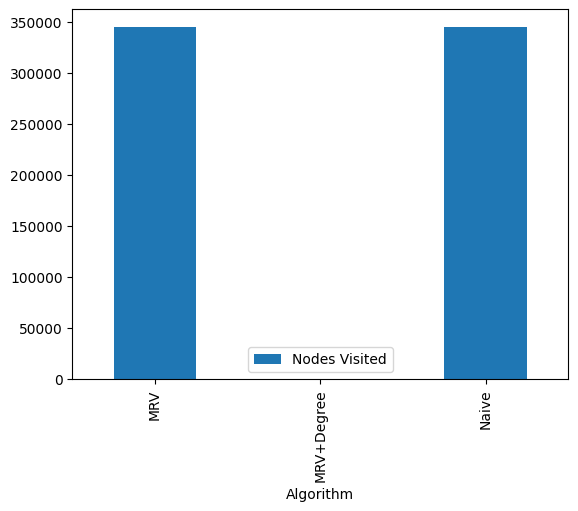

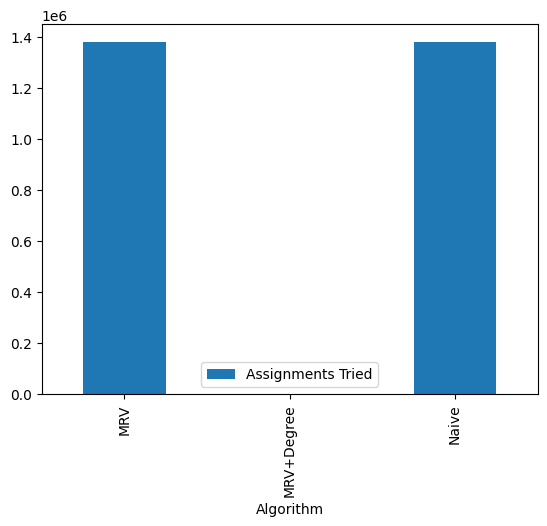

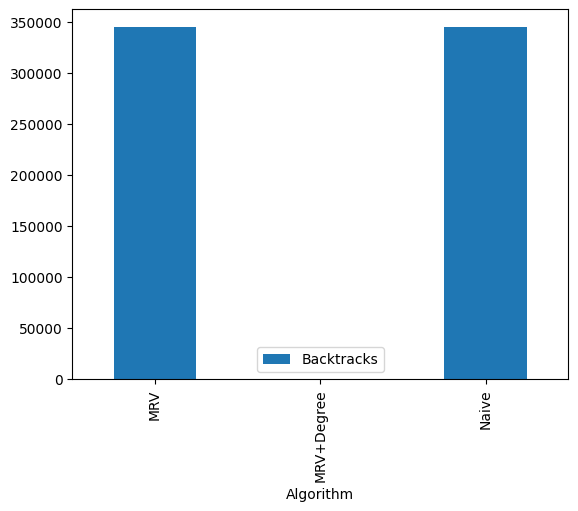

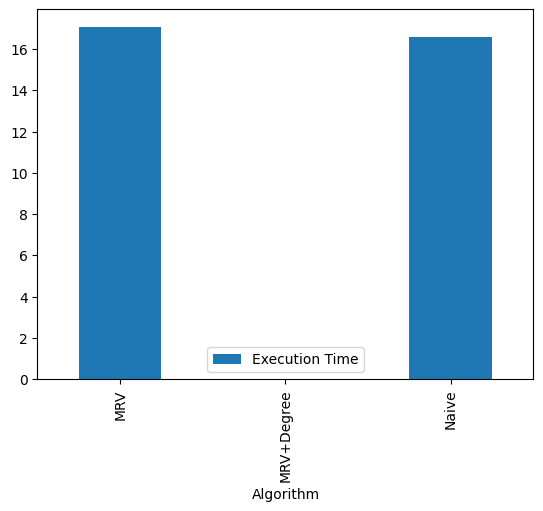

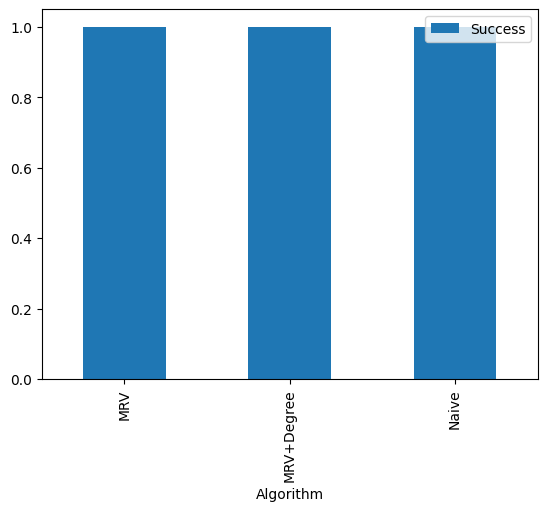

In [35]:
benchmark_summary.plot(
    x="Algorithm",
    y="Nodes Visited",
    kind="bar"
)

benchmark_summary.plot(
    x="Algorithm",
    y="Assignments Tried",
    kind="bar"
)

benchmark_summary.plot(
    x="Algorithm",
    y="Backtracks",
    kind="bar"
)

benchmark_summary.plot(
    x="Algorithm",
    y="Execution Time",
    kind="bar"
)

benchmark_summary.plot(
    x="Algorithm",
    y="Success",
    kind="bar"
)

<h3> Constraint Density </h3>

In [7]:
densities = [
    0.05,
    0.2,
    0.4,
]

In [10]:
num_trials = 1

density_results = []

for density in densities:
    for trial in range(num_trials):
        problem = generate_graph_coloring_csp(
            num_variables=30,
            num_colors=4,
            edge_probability=density,
        )

        for name, solver in solvers:
            result = run_solver_experiment(
                problem,
                solver,
            )

            result["Algorithm"] = name
            result["Constraint Density"] = density
            result["Trial"] = trial

            density_results.append(
                result
            )

In [11]:
density_df = pd.DataFrame(
    density_results
)

density_df

,Nodes Visited,Assignments Tried,Backtracks,Success,Execution Time,Algorithm,Constraint Density,Trial
0,31,42,0,True,0.000352,Naive,0.05,0
1,31,42,0,True,0.000576,MRV,0.05,0
2,31,42,0,True,0.000750,MRV+Degree,0.05,0
3,2621060,10484185,2621029,True,122.387032,Naive,0.20,0
4,2621060,10484185,2621029,True,127.640998,MRV,0.20,0
5,429,1661,398,True,0.021593,MRV+Degree,0.20,0
6,16597,66388,16597,False,0.784463,Naive,0.40,0
7,16597,66388,16597,False,0.863839,MRV,0.40,0
8,933,3732,933,False,0.070896,MRV+Degree,0.40,0


Given these results, we conclude that the medium density value, i.e. 0.2, is the hardest of all, and this is logical, because at a low density value, less restriction is imposed on the solution space, while at a medium value, in the solution space, there are possible paths but they are difficult to reach. And finally, naturally, again, a very high density is easier for the algorithms than the medium one, because many paths and branches are eliminated very quickly due to the high restriction imposed.

In [12]:
density_summary = (
    density_df
    .groupby(
        [
            "Constraint Density",
            "Algorithm",
        ]
    )
    [
        [
            "Nodes Visited",
            "Assignments Tried",
            "Backtracks",
            "Execution Time",
            "Success",
        ]
    ]
    .mean()
    .reset_index()
)

density_summary

,Constraint Density,Algorithm,Nodes Visited,Assignments Tried,Backtracks,Execution Time,Success
0,0.05,MRV,31.0,42.0,0.0,0.000576,1.0
1,0.05,MRV+Degree,31.0,42.0,0.0,0.000750,1.0
2,0.05,Naive,31.0,42.0,0.0,0.000352,1.0
3,0.20,MRV,2621060.0,10484185.0,2621029.0,127.640998,1.0
4,0.20,MRV+Degree,429.0,1661.0,398.0,0.021593,1.0
5,0.20,Naive,2621060.0,10484185.0,2621029.0,122.387032,1.0
6,0.40,MRV,16597.0,66388.0,16597.0,0.863839,0.0
7,0.40,MRV+Degree,933.0,3732.0,933.0,0.070896,0.0
8,0.40,Naive,16597.0,66388.0,16597.0,0.784463,0.0


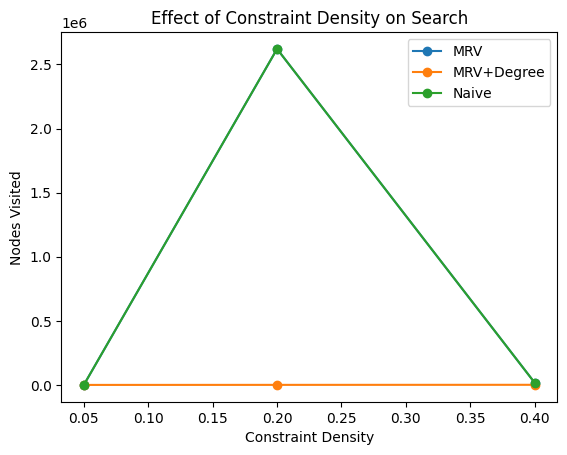

In [13]:
for algorithm in density_summary["Algorithm"].unique():
    subset = density_summary[
        density_summary["Algorithm"] == algorithm
    ]
    plt.plot(
        subset["Constraint Density"],
        subset["Nodes Visited"],
        marker="o",
        label=algorithm,
    )

plt.xlabel(
    "Constraint Density"
)
plt.ylabel(
    "Nodes Visited"
)
plt.legend()
plt.title(
    "Effect of Constraint Density on Search"
)
plt.show()

<h1> Forward Checking </h1>

In [4]:
solution_fc = backtracking_search_forward_checking(
    random_problem
)

solution_fc

{'X4': 0,
 'X18': 1,
 'X3': 2,
 'X0': 0,
 'X1': 2,
 'X5': 2,
 'X10': 1,
 'X15': 3,
 'X6': 1,
 'X7': 0,
 'X8': 3,
 'X11': 3,
 'X14': 2,
 'X12': 1,
 'X16': 1,
 'X17': 1,
 'X19': 0,
 'X2': 0,
 'X9': 1,
 'X13': 0}

In [5]:
len(solution_fc)

20

In [6]:
random_problem.is_consistent(
    solution_fc
)

True

<h3> dynamic mrv forward </h3>

In [3]:
solution_dynamic_fc = (
    backtracking_search_dynamic_mrv_forward_checking(
        random_problem
    )
)

solution_dynamic_fc

{'X3': 0,
 'X10': 1,
 'X9': 0,
 'X4': 2,
 'X8': 1,
 'X15': 1,
 'X14': 2,
 'X6': 0,
 'X13': 1,
 'X16': 2,
 'X2': 0,
 'X11': 1,
 'X7': 2,
 'X17': 1,
 'X0': 0,
 'X1': 2,
 'X12': 2,
 'X5': 1,
 'X18': 2,
 'X19': 0}

In [4]:
len(solution_dynamic_fc)

20

In [5]:
random_problem.is_consistent(
    solution_dynamic_fc
)

True

<h3> dynamic mrv forward + stats </h3>

In [3]:
solution_dynamic_fc_stats, stats_dynamic_fc = (
    backtracking_search_dynamic_fc_with_stats(
        random_problem
    )
)

solution_dynamic_fc_stats

{'X15': 0,
 'X6': 1,
 'X13': 2,
 'X8': 0,
 'X0': 0,
 'X2': 0,
 'X7': 1,
 'X16': 2,
 'X12': 0,
 'X17': 2,
 'X14': 1,
 'X19': 2,
 'X1': 0,
 'X4': 1,
 'X9': 2,
 'X18': 1,
 'X3': 2,
 'X5': 0,
 'X10': 2,
 'X11': 1}

In [4]:
stats_dynamic_fc.summary()

{'Nodes Visited': 21, 'Assignments Tried': 20, 'Backtracks': 0}

| Algorithm                               | Nodes Visited | Assignments Tried | Backtracks |
| --------------------------------------- | ------------: | ----------------: | ---------: |
| Naive Backtracking                      |     1,518,819 |         6,075,226 |  1,518,788 |
| MRV                                     |     1,518,819 |         6,075,226 |  1,518,788 |
| MRV + Degree                            |            57 |               178 |         26 |
| Dynamic MRV + Degree + Forward Checking |            21 |                20 |          0 |


| Technique        | What makes it better?               |
| ---------------- | ----------------------------------- |
| MRV              | Better Variable Selection           |
| Degree           | Breaking Ties Between Variables     |
| Forward Checking | Eliminate impossible paths before they get too deep. |


**In simple terms:**

MRV says: Choose the most difficult variable first.

Degree says: If there are several difficult ones, choose the most important one.

Forward Checking says: After choosing, check the future so that we don't go down a dead end.

<h1> Arc Consistency (AC-3) </h1>

Backtracking:</br>
Select → Go Forward → Return if Failed

Forward Checking:</br>
Select → Reduce Direct Neighbors

AC-3:</br>
Before Search → Propagate Entire Constraint Network<

In [5]:
domains_copy = random_problem.copy_domains()

result = ac3(
    random_problem,
    domains_copy,
)

result

True

In [6]:
domains_copy

{'X0': [0, 1, 2, 3],
 'X1': [0, 1, 2, 3],
 'X2': [0, 1, 2, 3],
 'X3': [0, 1, 2, 3],
 'X4': [0, 1, 2, 3],
 'X5': [0, 1, 2, 3],
 'X6': [0, 1, 2, 3],
 'X7': [0, 1, 2, 3],
 'X8': [0, 1, 2, 3],
 'X9': [0, 1, 2, 3],
 'X10': [0, 1, 2, 3],
 'X11': [0, 1, 2, 3],
 'X12': [0, 1, 2, 3],
 'X13': [0, 1, 2, 3],
 'X14': [0, 1, 2, 3],
 'X15': [0, 1, 2, 3],
 'X16': [0, 1, 2, 3],
 'X17': [0, 1, 2, 3],
 'X18': [0, 1, 2, 3],
 'X19': [0, 1, 2, 3]}

<h3> AC-3 + Backtracking Solver </h3>

AC-3
 +
Dynamic MRV
 +
Degree
 +
Forward Checking

Forward Checking: One-step lookahead </br>
AC-3: Full constraint propagation

In [3]:
solution_ac3 = backtracking_search_ac3(
    random_problem
)

solution_ac3

{'X3': 0,
 'X4': 1,
 'X16': 2,
 'X1': 0,
 'X9': 1,
 'X5': 0,
 'X14': 1,
 'X2': 2,
 'X11': 0,
 'X0': 2,
 'X17': 3,
 'X6': 1,
 'X15': 3,
 'X7': 0,
 'X8': 1,
 'X10': 1,
 'X18': 0,
 'X12': 1,
 'X13': 0,
 'X19': 1}

In [4]:
random_problem.is_consistent(
    solution_ac3
)

True

<h3> AC-3 + Backtracking Solver + Stats </h3>

In [3]:
solution_ac3_stats, stats_ac3 = (
    backtracking_search_ac3_with_stats(
        random_problem
    )
)

solution_ac3_stats

{'X0': 0,
 'X14': 1,
 'X12': 0,
 'X6': 2,
 'X1': 0,
 'X18': 1,
 'X7': 0,
 'X4': 1,
 'X10': 2,
 'X17': 0,
 'X9': 1,
 'X3': 2,
 'X15': 2,
 'X11': 1,
 'X2': 1,
 'X5': 0,
 'X8': 1,
 'X13': 0,
 'X16': 0,
 'X19': 0}

In [4]:
stats_ac3.summary()

{'Nodes Visited': 21, 'Assignments Tried': 20, 'Backtracks': 0}

| Algorithm                                      | Nodes Visited | Assignments Tried | Backtracks |
| ---------------------------------------------- | ------------: | ----------------: | ---------: |
| Dynamic MRV + Degree + Forward Checking        |            21 |                20 |          0 |
| AC-3 + Dynamic MRV + Degree + Forward Checking |            21 |                20 |          0 |


There is no improvement here due to the nature of the problem, because for the color scheme problem, each element has some support in other nodes. In more difficult CSPs, especially when the domains are constrained, this method is very powerful.

<h1> LCV (Least Constraining Value) </h1>

When we select Variable:

X = ?

Which Value should we try first?

This is where LCV comes in.

LCV says to choose an amount that gives more freedom for the future.

LCV is not a Solver itself.</br>
It is like MRV.</br>
That is, it must be used in the new Solver.

**Differences in Heuristics**

| Technique        | Question                                        |
| ---------------- | ----------------------------------------------- |
| MRV              | Which Variable should I choose?                 |
| Degree           | If it's a tie, which is more important?         |
| LCV              | Which value should I try first for this variable?|
| Forward Checking | What happens to the future after the election?   |
| AC-3             | How do I propagate the entire network?           |


<h3> MRV + Degree + LCV + Forward Checking </h3>

Variable Selection:</br>
Dynamic MRV
+
Degree


Value Selection:</br>
LCV


Propagation:</br>
Forward Checking

In [3]:
solution_lcv = backtracking_search_lcv(
    random_problem
)

In [4]:
random_problem.is_consistent(
    solution_lcv
)

True

| Algorithm                       | Variable Selection   | Value Ordering | Propagation      |
| ------------------------------- | -------------------- | -------------- | ---------------- |
| Naive                           | First Variable       | First Value    | None             |
| MRV + Degree                    | MRV + Degree         | First Value    | None             |
| Dynamic MRV + FC                | Dynamic MRV + Degree | First Value    | Forward Checking |
| AC3 + Dynamic MRV + FC          | Dynamic MRV + Degree | First Value    | AC-3 + FC        |
| Dynamic MRV + Degree + LCV + FC | Dynamic MRV + Degree | LCV            | Forward Checking |


Now, for a fair comparison, all solvers should:

Run on the same CSP.

Tested with several different trials.

Why?

Because the generator is random.

In [4]:
benchmark_solvers = [
    (
        "Naive",
        backtracking_search_with_stats
    ),
    (
        "MRV+Degree",
        backtracking_search_mrv_degree_with_stats
    ),
    (
        "Dynamic MRV+FC",
        backtracking_search_dynamic_fc_with_stats
    ),
    (
        "AC3+Dynamic MRV+FC",
        backtracking_search_ac3_with_stats
    ),
    (
        "Dynamic MRV+Degree+LCV+FC",
        backtracking_search_lcv_with_stats
    ),
]

In [5]:
final_results = []
total_trials = 1

for trial in range(total_trials):
    problem = generate_graph_coloring_csp(
        num_variables=30,
        num_colors=4,
        edge_probability=0.2,
    )

    for name, solver in benchmark_solvers:
        result = run_solver_experiment(
            problem,
            solver,
        )

        result["Algorithm"] = name
        result["Trial"] = trial

        final_results.append(
            result
        )

In [6]:
final_df = pd.DataFrame(
    final_results
)

final_df

,Nodes Visited,Assignments Tried,Backtracks,Success,Execution Time,Algorithm,Trial
0,1503435,6013683,1503404,True,78.094800,Naive,0
1,379,1466,348,True,0.021043,MRV+Degree,0
2,54,60,23,True,0.011953,Dynamic MRV+FC,0
3,54,60,23,True,0.022450,AC3+Dynamic MRV+FC,0
4,54,60,23,True,0.017387,Dynamic MRV+Degree+LCV+FC,0


### Benchmark Analysis

The results demonstrate the significant impact of heuristic-guided search in CSP solving. Naive backtracking explored more than 1.5 million nodes due to uninformed search, while MRV and Degree heuristics dramatically reduced the search space. Adding Forward Checking further improved efficiency by pruning inconsistent branches early, reducing the number of visited nodes from hundreds to tens. In this experiment, AC-3 did not provide additional pruning benefits because the graph-coloring constraints allowed most domain values to remain arc-consistent. Similarly, LCV did not significantly change the search behavior, indicating that its effectiveness depends on the structure of the constraint network.

In [8]:
final_summary = (
    final_df
    .groupby("Algorithm")
    [
        [
            "Nodes Visited",
            "Assignments Tried",
            "Backtracks",
            "Execution Time",
            "Success",
        ]
    ]
    .mean()
    .reset_index()
)

final_summary

,Algorithm,Nodes Visited,Assignments Tried,Backtracks,Execution Time,Success
0,AC3+Dynamic MRV+FC,54.0,60.0,23.0,0.022450,1.0
1,Dynamic MRV+Degree+LCV+FC,54.0,60.0,23.0,0.017387,1.0
2,Dynamic MRV+FC,54.0,60.0,23.0,0.011953,1.0
3,MRV+Degree,379.0,1466.0,348.0,0.021043,1.0
4,Naive,1503435.0,6013683.0,1503404.0,78.094800,1.0


### Stres Test

In [23]:
large_problem = generate_graph_coloring_csp(
    num_variables=90,
    num_colors=7,
    edge_probability=0.2,
)

In [24]:
large_benchmark_solvers = [
    (
        "Dynamic MRV+FC",
        backtracking_search_dynamic_fc_with_stats
    ),
    (
        "AC3+Dynamic MRV+FC",
        backtracking_search_ac3_with_stats
    ),
    (
        "Dynamic MRV+Degree+LCV+FC",
        backtracking_search_lcv_with_stats
    ),
]

In [25]:
large_results = []

for name, solver in large_benchmark_solvers:
    solution, stats = solver(
        large_problem
    )
    result = stats.summary()
    result["Algorithm"] = name
    large_results.append(
        result
    )

In [26]:
large_df = pd.DataFrame(
    large_results
)

large_df

,Nodes Visited,Assignments Tried,Backtracks,Algorithm
0,189,207,98,Dynamic MRV+FC
1,189,207,98,AC3+Dynamic MRV+FC
2,91,90,0,Dynamic MRV+Degree+LCV+FC


In [27]:
solution, stats = backtracking_search_dynamic_fc_with_stats(
    large_problem
)

solution

{'X8': 0,
 'X80': 1,
 'X24': 2,
 'X25': 0,
 'X62': 3,
 'X42': 2,
 'X65': 1,
 'X26': 2,
 'X79': 4,
 'X0': 1,
 'X49': 3,
 'X78': 4,
 'X2': 5,
 'X7': 1,
 'X89': 2,
 'X21': 1,
 'X71': 4,
 'X67': 2,
 'X9': 3,
 'X69': 0,
 'X39': 3,
 'X50': 5,
 'X16': 3,
 'X1': 4,
 'X64': 5,
 'X72': 1,
 'X13': 0,
 'X77': 5,
 'X81': 4,
 'X52': 6,
 'X45': 2,
 'X35': 0,
 'X54': 3,
 'X76': 4,
 'X20': 0,
 'X63': 4,
 'X30': 2,
 'X66': 6,
 'X57': 4,
 'X15': 0,
 'X75': 5,
 'X6': 6,
 'X14': 6,
 'X53': 5,
 'X58': 2,
 'X56': 5,
 'X73': 6,
 'X12': 6,
 'X36': 4,
 'X33': 6,
 'X19': 0,
 'X59': 5,
 'X60': 1,
 'X48': 3,
 'X3': 4,
 'X11': 5,
 'X46': 6,
 'X70': 2,
 'X74': 3,
 'X68': 5,
 'X27': 0,
 'X17': 3,
 'X86': 6,
 'X44': 1,
 'X83': 4,
 'X38': 3,
 'X31': 6,
 'X88': 2,
 'X22': 4,
 'X28': 2,
 'X82': 5,
 'X84': 5,
 'X51': 0,
 'X55': 3,
 'X29': 1,
 'X5': 6,
 'X43': 1,
 'X37': 4,
 'X47': 4,
 'X87': 3,
 'X61': 3,
 'X32': 1,
 'X40': 0,
 'X34': 1,
 'X18': 2,
 'X85': 6,
 'X10': 2,
 'X23': 5,
 'X41': 2,
 'X4': 1}

### Large-Scale CSP Benchmark Analysis

A larger graph-coloring problem was evaluated to analyze the impact of advanced heuristics. Dynamic MRV combined with Forward Checking reduced unnecessary exploration but still required several backtracking operations due to non-optimal value ordering. Adding AC-3 did not improve the results because the graph-coloring constraints remained mostly arc-consistent before search. In contrast, incorporating the Least Constraining Value (LCV) heuristic significantly improved performance by selecting values that preserved more flexibility for neighboring variables, resulting in fewer explored nodes and eliminating backtracking in this experiment.